# 第四问重解第二问：正式结果绘图

全部绘图代码在下方单元格；仅读取保存的CSV。

In [1]:
"""Four vector figures from saved official CSV; shared verbatim with the notebook."""
from pathlib import Path
import os
import tempfile
os.environ.setdefault('MPLCONFIGDIR',str(Path(tempfile.gettempdir())/'problem4_mpc_matplotlib'))
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import font_manager


def locate():
    for p in (Path.cwd(),*Path.cwd().parents):
        if (p/'outputs'/'official_schedule.csv').exists() and (p/'result4-2.xlsx').exists():return p
        if (p/'4test'/'outputs'/'official_schedule.csv').exists():return p/'4test'
    raise FileNotFoundError('请从4test或其父目录运行')


def style():
    paths=[Path(os.environ.get('PROBLEM4_FONT','C:/Windows/Fonts/msyh.ttc')),
           Path('C:/Windows/Fonts/simhei.ttf')]
    font=next((p for p in paths if p.exists()),None)
    if not font:raise FileNotFoundError('请设置PROBLEM4_FONT为中文字体文件')
    font_manager.fontManager.addfont(str(font))
    plt.rcParams.update({'font.family':font_manager.FontProperties(fname=str(font)).get_name(),
        'font.size':10,'axes.spines.top':False,'axes.spines.right':False,
        'axes.edgecolor':'#CBD5E1','axes.labelcolor':'#334155','xtick.color':'#475569',
        'ytick.color':'#475569','axes.unicode_minus':False,'pdf.fonttype':42,
        'savefig.dpi':180,'figure.facecolor':'white','axes.facecolor':'white'})


def save(fig,out,name):
    out.mkdir(exist_ok=True)
    for artist in fig.findobj():
        if hasattr(artist,'set_rasterized'):artist.set_rasterized(False)
    fig.savefig(out/f'{name}.pdf',metadata={'CreationDate':None,'ModDate':None})
    fig.savefig(out/f'{name}.png',metadata={'Software':'4test simple MPC'})
    plt.close(fig)


def create_figures():
    base=locate();out=Path(os.environ.get('PROBLEM4_FIGURE_DIR',str(base/'figures')));style()
    new=json.loads((base/'outputs'/'official_summary.json').read_text(encoding='utf-8'))
    old=json.loads((base/'archives'/'joint_v1'/'summary.json').read_text(encoding='utf-8'))
    daily=pd.read_csv(base/'outputs'/'official_daily.csv',parse_dates=['date'])
    previous=pd.read_csv(base/'archives'/'joint_v1'/'daily_summary.csv',parse_dates=['date'])
    previous=previous[(previous.strategy=='official')&(previous.date>='2025-02-01')]
    forecasts=pd.read_csv(base/'outputs'/'official_forecasts.csv',parse_dates=['date'])
    schedule=pd.read_csv(base/'outputs'/'official_schedule.csv',parse_dates=['date'])
    slate='#6C879C';blue='#287C9E';orange='#D57935'
    # One: costs; small improvement remains legible in the right panel.
    fig,ax=plt.subplots(1,2,figsize=(12,4.2),constrained_layout=True)
    names=['原联合方案','简化预测＋MPC'];y=np.arange(2)
    normal=np.array([old['planned_cost_yuan'],new['planned_cost_yuan']])/1e4
    urgent=np.array([old['emergency_cost_yuan'],new['emergency_cost_yuan']])/1e4
    ax[0].barh(y,normal,color=[slate,blue],label='正常购电费')
    ax[0].barh(y,urgent,left=normal,color=orange,label='五倍紧急购电费')
    ax[0].set(yticks=y,yticklabels=names,xlabel='总费用（万元）');ax[0].invert_yaxis()
    ax[0].legend(loc='upper center',bbox_to_anchor=(.5,1.13),ncol=2,frameon=False)
    ax[0].grid(axis='x',color='#E2E8F0',lw=.6);ax[0].set_axisbelow(True)
    saving=(old['total_cost_yuan']-new['total_cost_yuan'])/1e4
    urgent_saved=(old['emergency_kwh']-new['emergency_kwh'])/1e4
    ax[1].bar(['总费用节省\n（万元）','紧急电量减少\n（万kWh）'],[saving,urgent_saved],color=[blue,orange])
    for i,v in enumerate([saving,urgent_saved]):ax[1].text(i,v+.15,f'{v:.2f}',ha='center')
    ax[1].set_ylim(0,max(saving,urgent_saved)*1.2);ax[1].grid(axis='y',color='#E2E8F0',lw=.6)
    save(fig,out,'cost_comparison')
    # Two: monthly realized savings and emergency volume, same days.
    a=daily.groupby(daily.date.dt.month).agg(total=('total_cost_yuan','sum'),urgent=('emergency_kwh','sum'))
    b=previous.groupby(previous.date.dt.month).agg(total=('total_cost_yuan','sum'),urgent=('emergency_kwh','sum'))
    x=np.arange(2,13);fig,ax=plt.subplots(2,1,figsize=(11,6),sharex=True,constrained_layout=True)
    ax[0].bar(x,(b.total-a.total).to_numpy()/1e4,color=np.where((b.total-a.total)>0,blue,orange))
    ax[0].axhline(0,color=slate,lw=.7);ax[0].set_ylabel('月费用节省（万元）')
    ax[1].plot(x,b.urgent.to_numpy()/1e4,'o-',color=slate,label='原联合方案')
    ax[1].plot(x,a.urgent.to_numpy()/1e4,'o-',color=orange,label='简化预测＋MPC')
    ax[1].set(xlabel='2025年月',ylabel='紧急电量（万kWh）',xticks=x)
    ax[1].legend(frameon=False,ncol=2);[p.grid(axis='y',color='#E2E8F0',lw=.6) for p in ax]
    save(fig,out,'monthly_cost_emergency')
    # Three: the measurable forecast improvement by month.
    f=forecasts.assign(month=forecasts.date.dt.month,
        old_error=lambda z:abs(z.old_load_forecast_kwh-z.actual_load_kwh),
        new_error=lambda z:abs(z.new_load_forecast_kwh-z.actual_load_kwh))
    m=f.groupby('month')[['old_error','new_error']].mean()
    fig,ax=plt.subplots(figsize=(11,3.8),constrained_layout=True)
    ax.plot(m.index,m.old_error,'o-',color=slate,label='原负载预测')
    ax.plot(m.index,m.new_error,'o-',color=blue,label='日总量×同类型日形状')
    ax.set(xlabel='2025年月',ylabel='负载预测MAE（kWh/10分钟）',xticks=x)
    ax.legend(frameon=False);ax.grid(color='#E2E8F0',lw=.6)
    save(fig,out,'forecast_accuracy')
    # Four: physical ten-minute dispatch on the specified June 21.
    s=schedule[schedule.date==pd.Timestamp('2025-06-21')]
    t=s.slot.to_numpy()/6;fig,ax=plt.subplots(3,1,figsize=(12,8),sharex=True,constrained_layout=True)
    ax[0].plot(t,s.price_yuan_per_kwh,color=orange);ax[0].set_ylabel('当日电价（元/kWh）')
    ax[1].plot(t,s.load_kwh,color=slate,label='负载')
    ax[1].plot(t,s.pv_kwh,color='#70A87D',label='光伏')
    ax[1].plot(t,s.plan_purchase_kwh,color=blue,label='计划购电')
    ax[1].fill_between(t,s.charge_kwh,alpha=.35,color='#70A87D',label='充电')
    ax[1].fill_between(t,-s.discharge_kwh,alpha=.35,color=orange,label='放电（负向）')
    ax[1].set_ylabel('每十分钟电量（kWh）');ax[1].legend(ncol=5,frameon=False)
    ax[2].plot(t,s.soc_start_kwh,color=blue,label='储电量')
    ax[2].axhline(1200,color=orange,ls='--',lw=.8);ax[2].axhline(10800,color=orange,ls='--',lw=.8)
    ax[2].set(xlim=(0,24),xticks=np.arange(0,25,2),xlabel='6月21日时刻（小时）',ylabel='储电量（kWh）')
    for p in ax:p.grid(axis='y',color='#E2E8F0',lw=.6)
    save(fig,out,'dispatch_june21')
    print('四组PDF/PNG图已保存',flush=True)




四组PDF/PNG图已保存


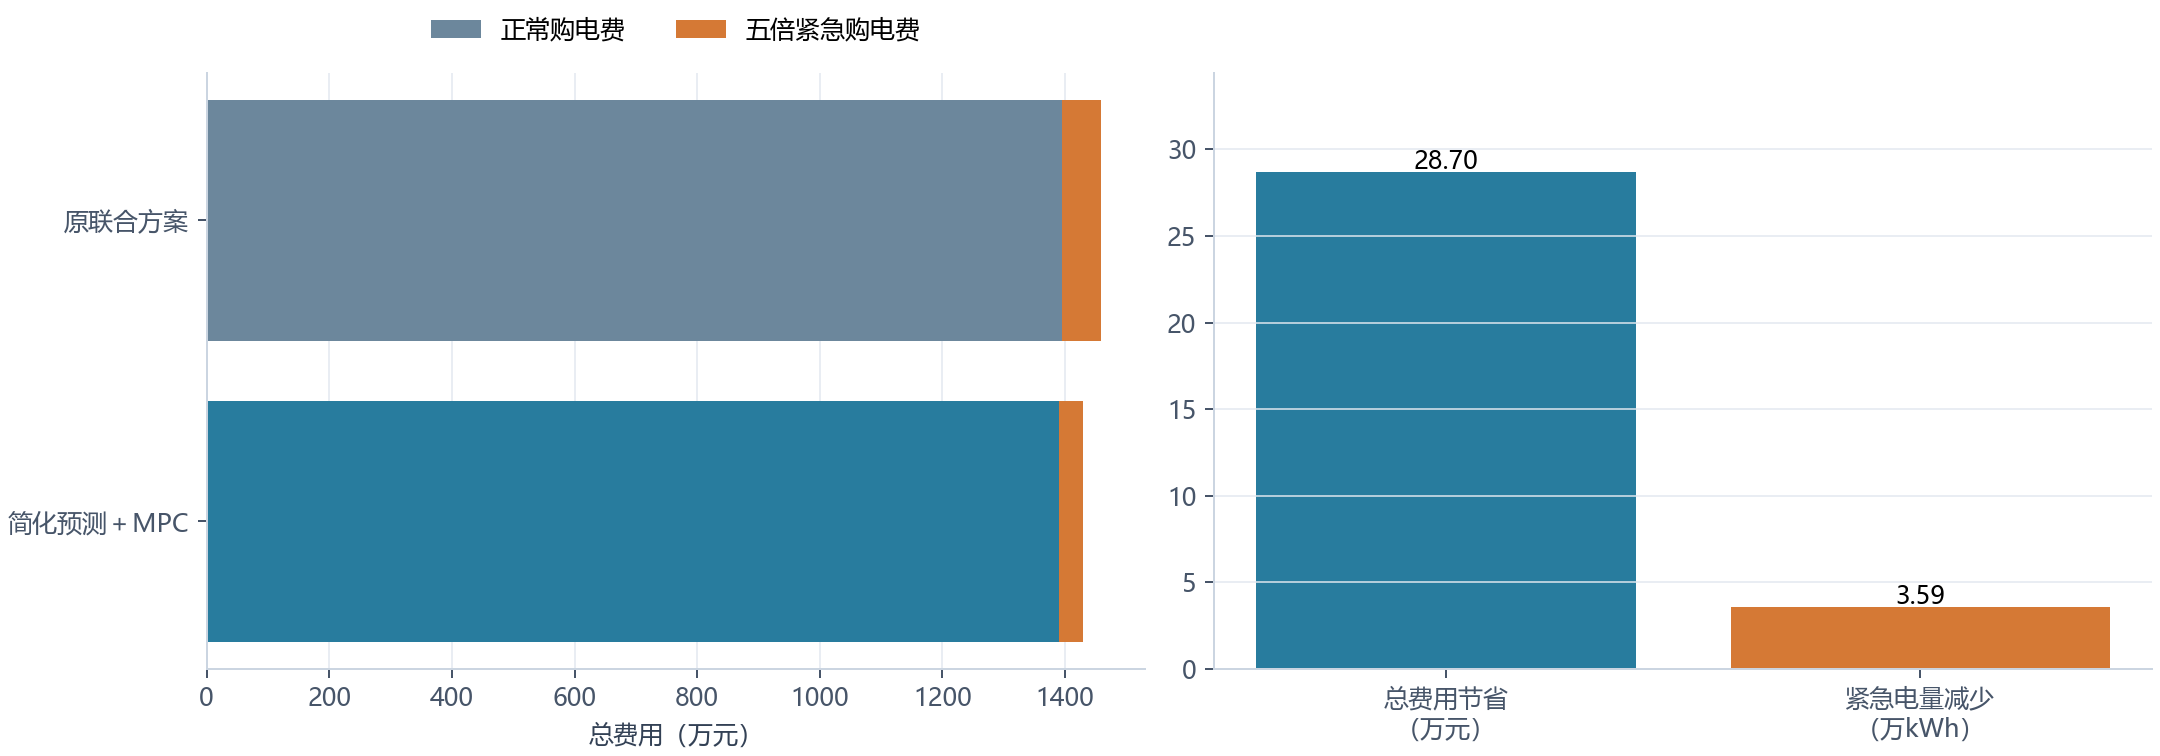

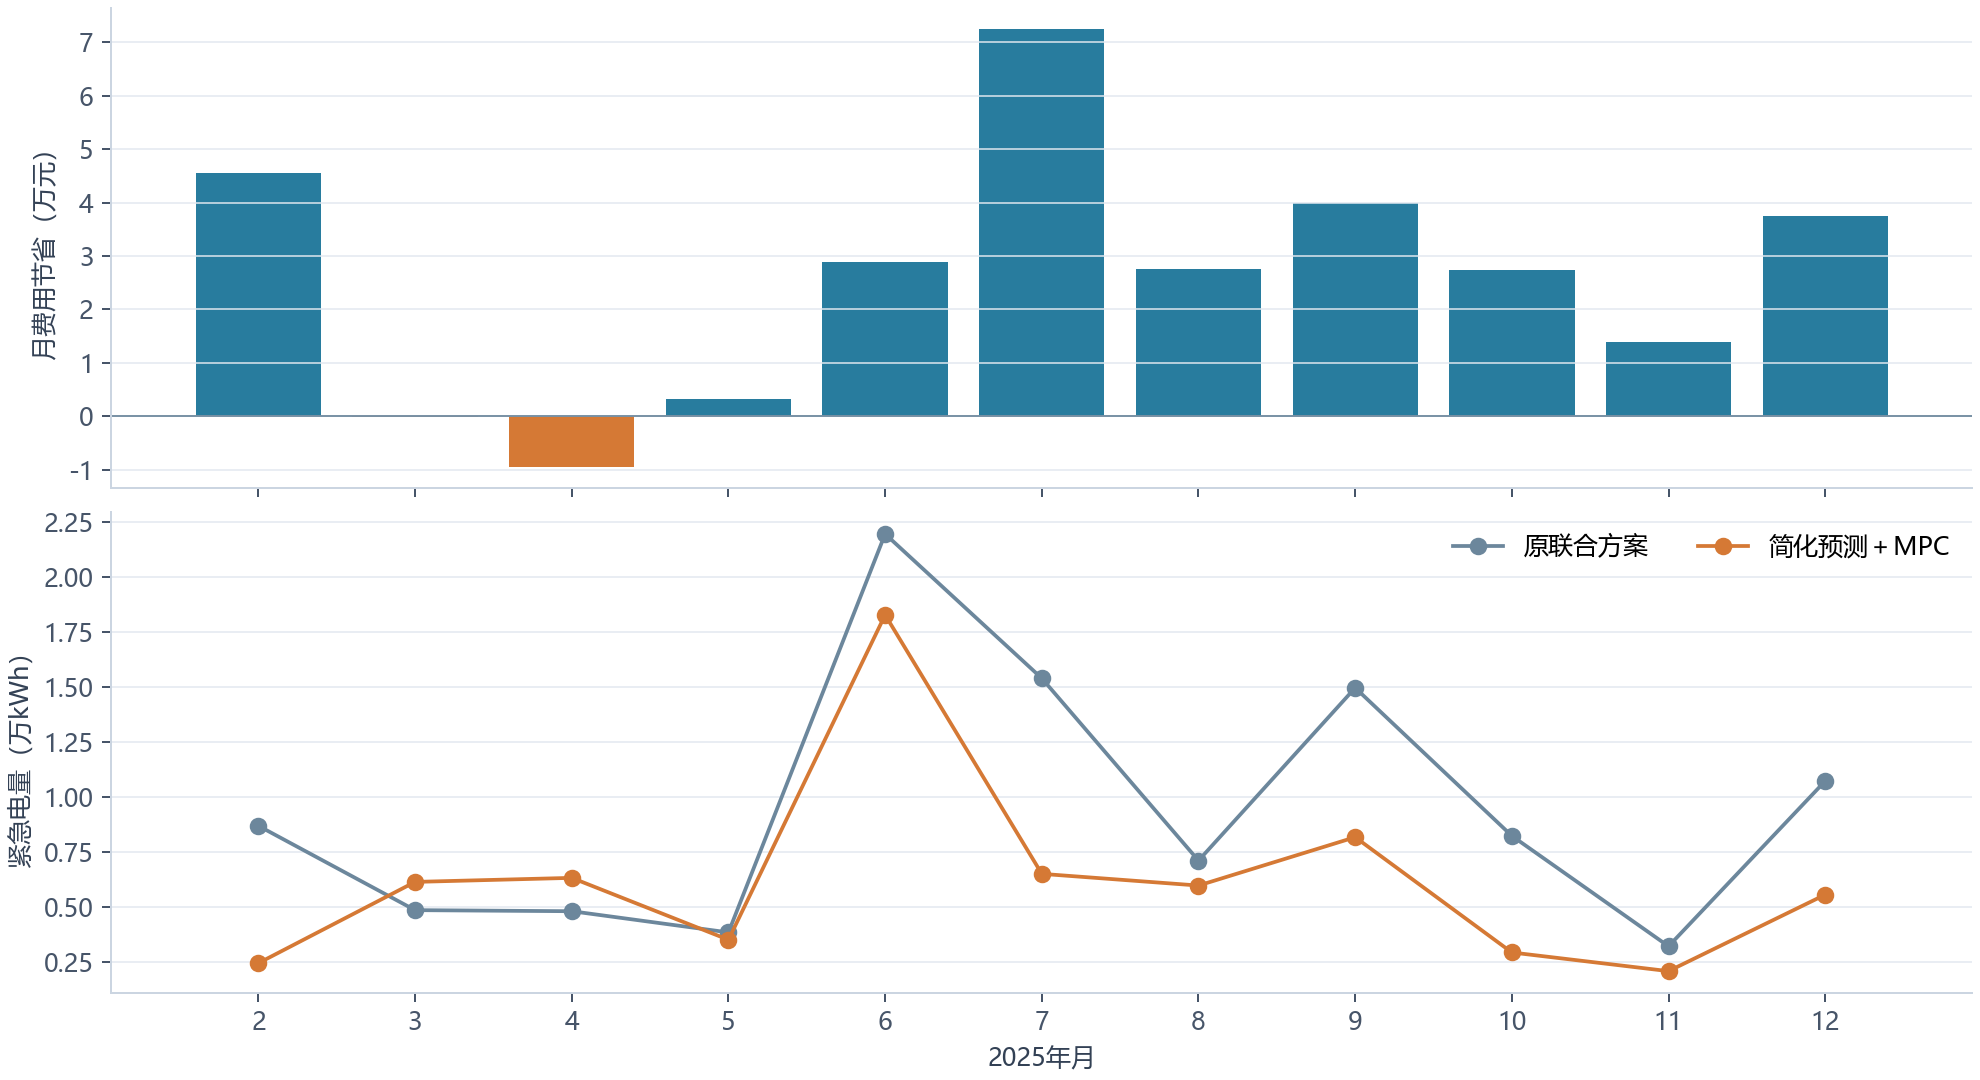

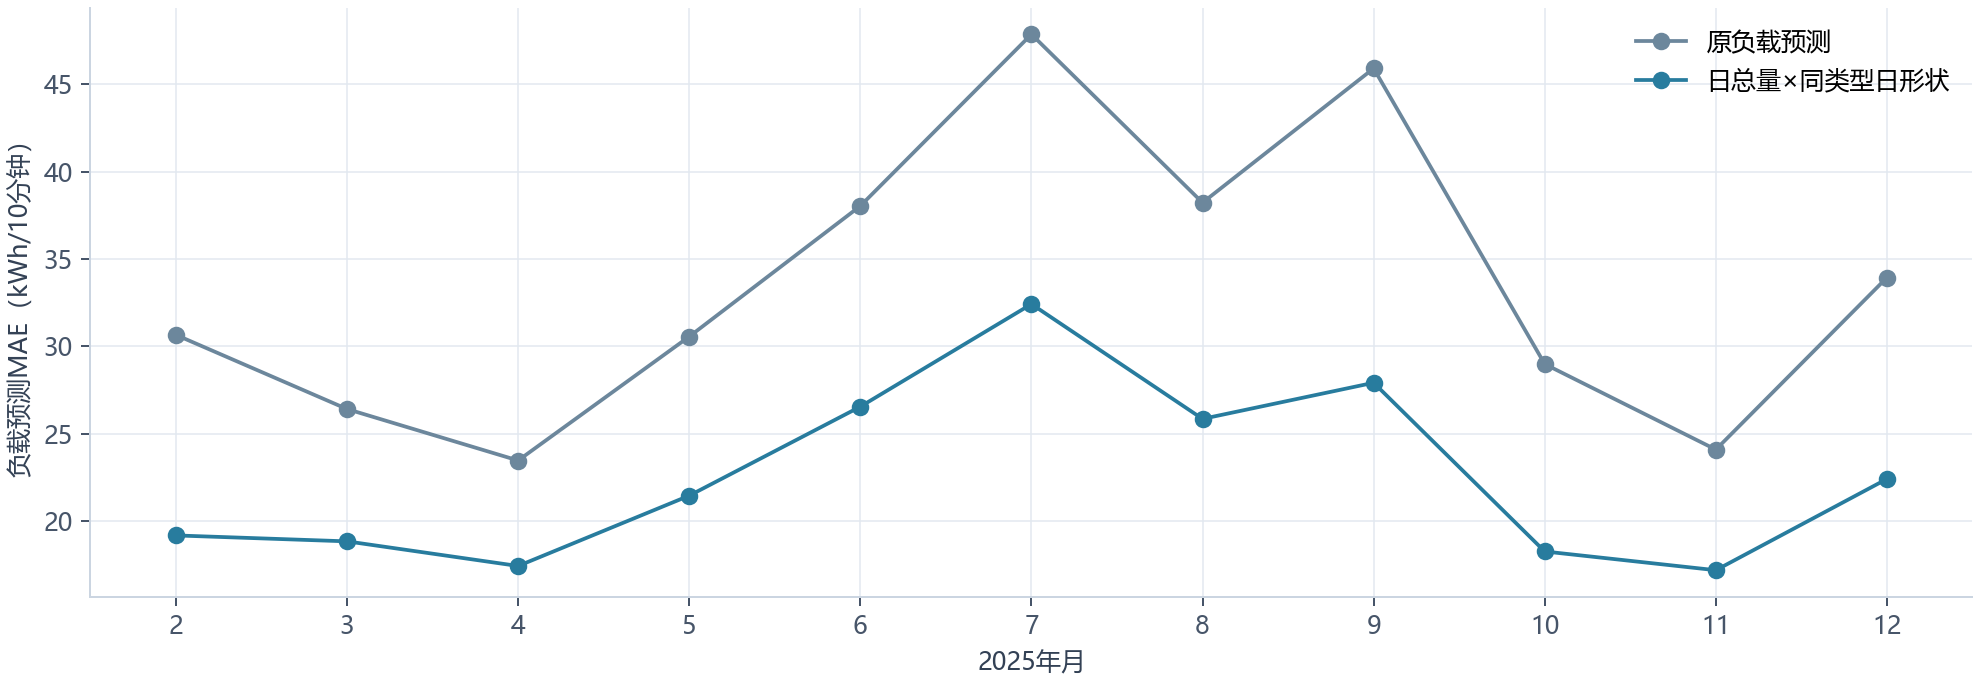

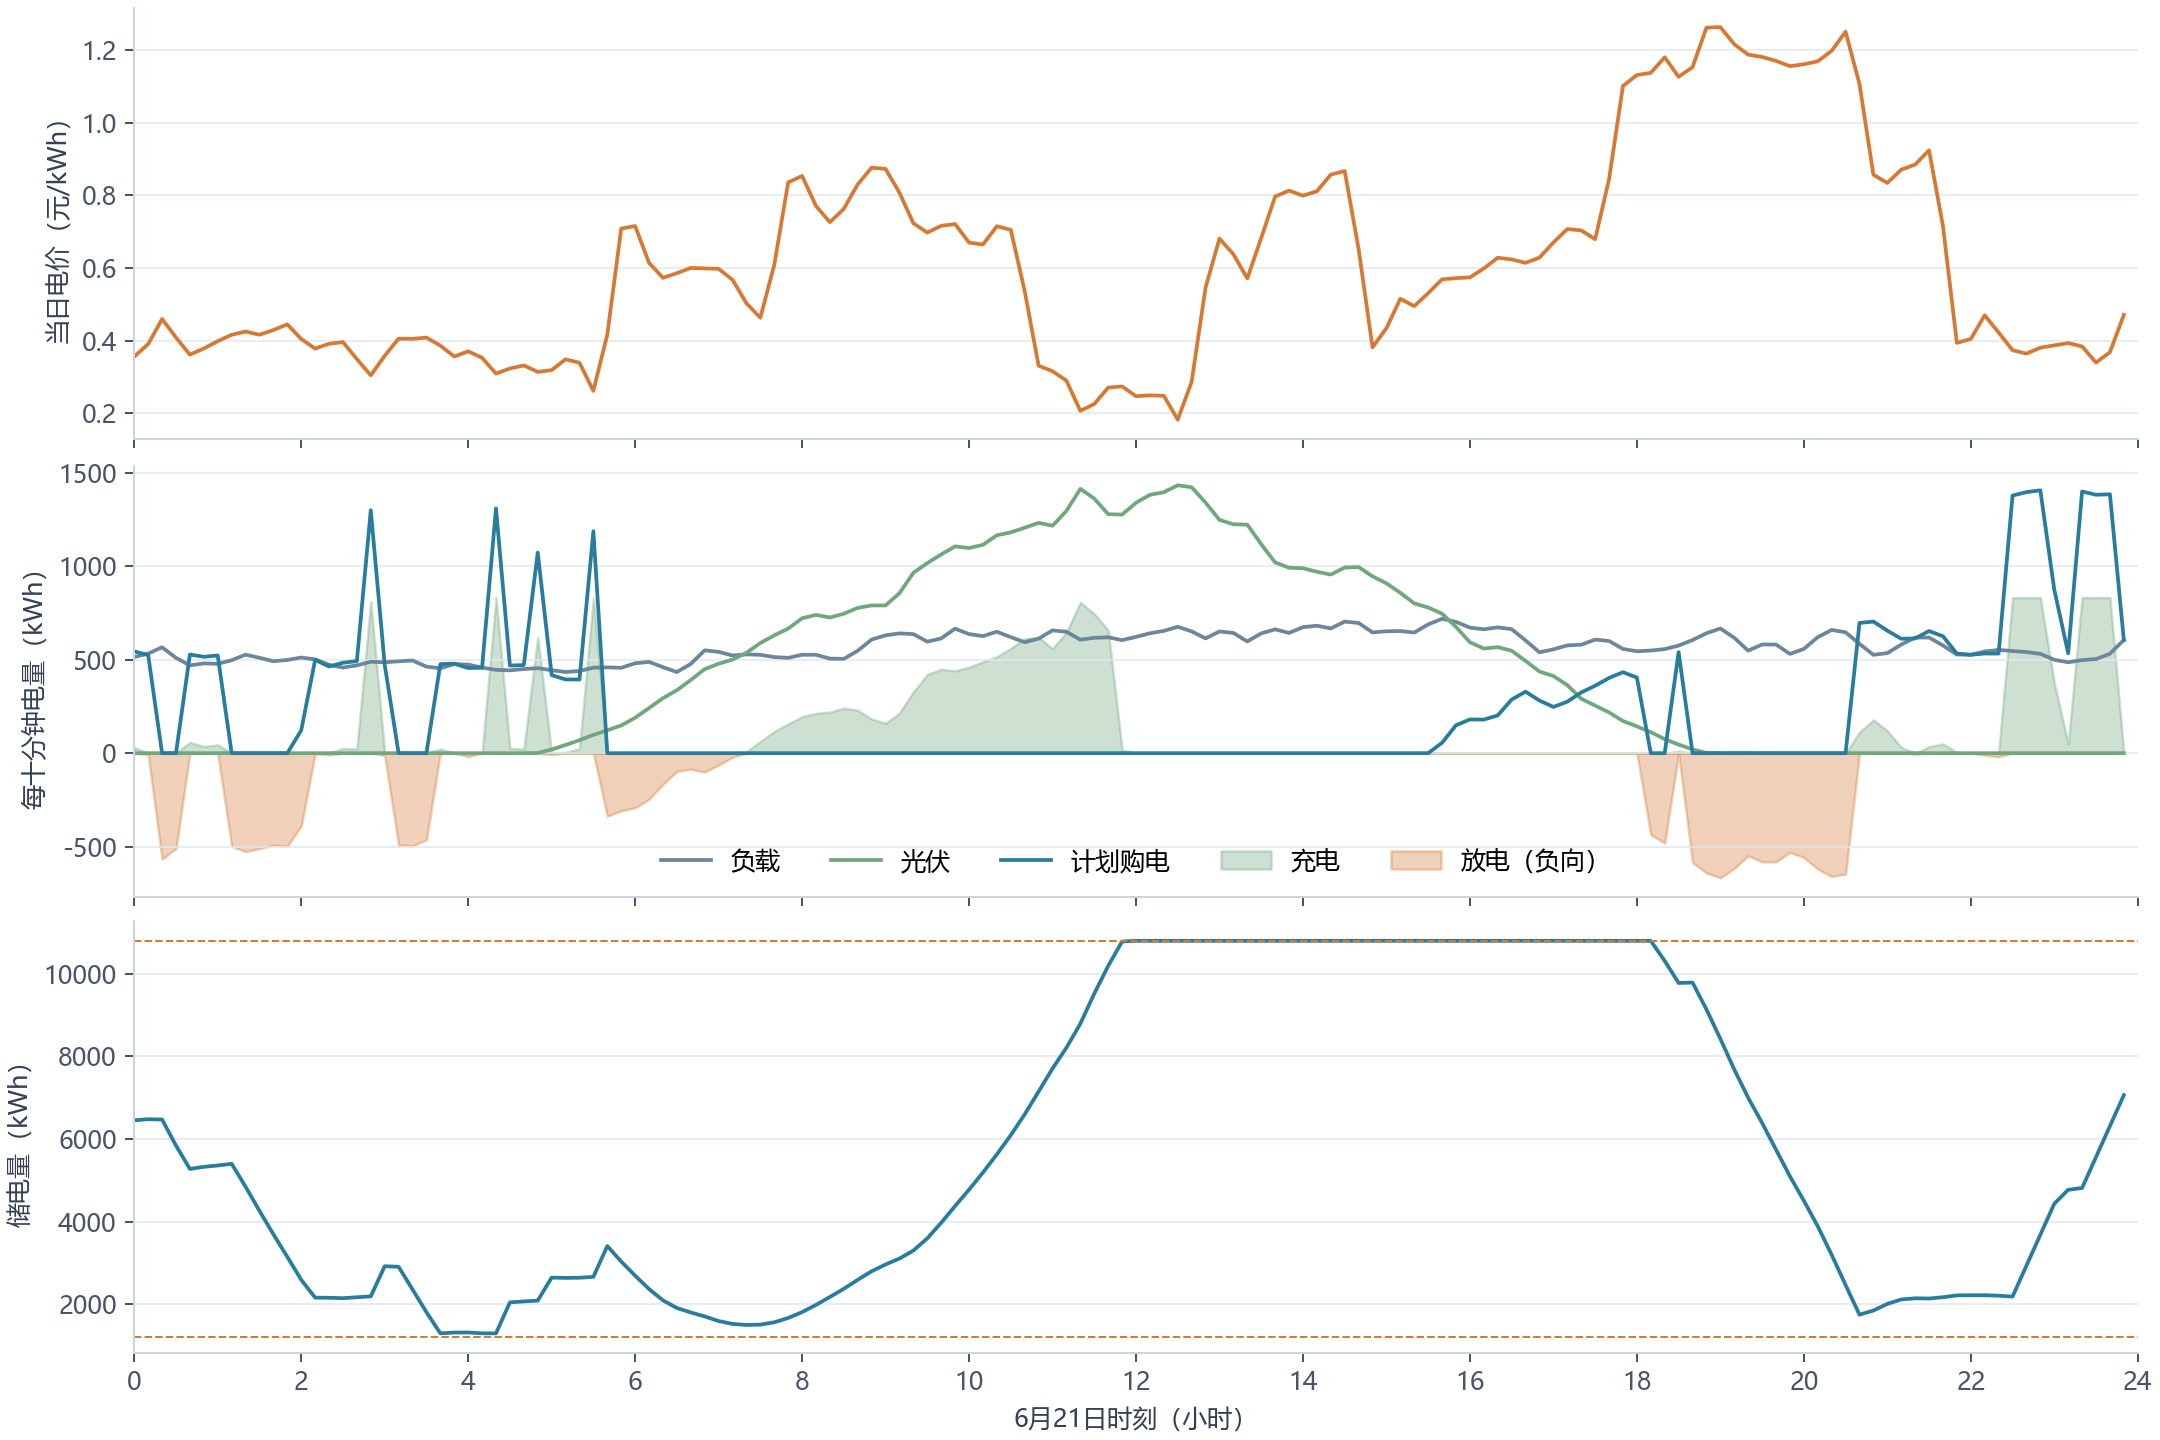

In [2]:
create_figures()
from IPython.display import display, Image
for name in ('cost_comparison','monthly_cost_emergency','forecast_accuracy','dispatch_june21'):
    display(Image(filename=str(Path(os.environ.get('PROBLEM4_FIGURE_DIR',str(locate()/'figures')))/(name+'.png'))))